<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data co

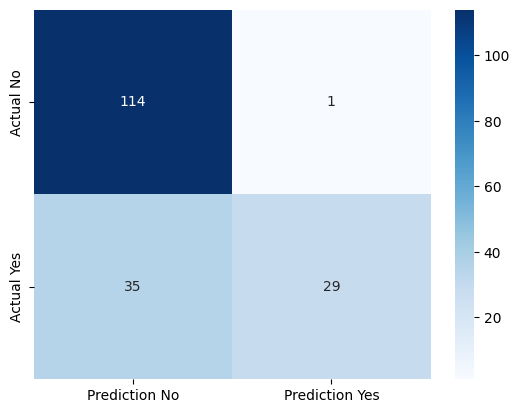

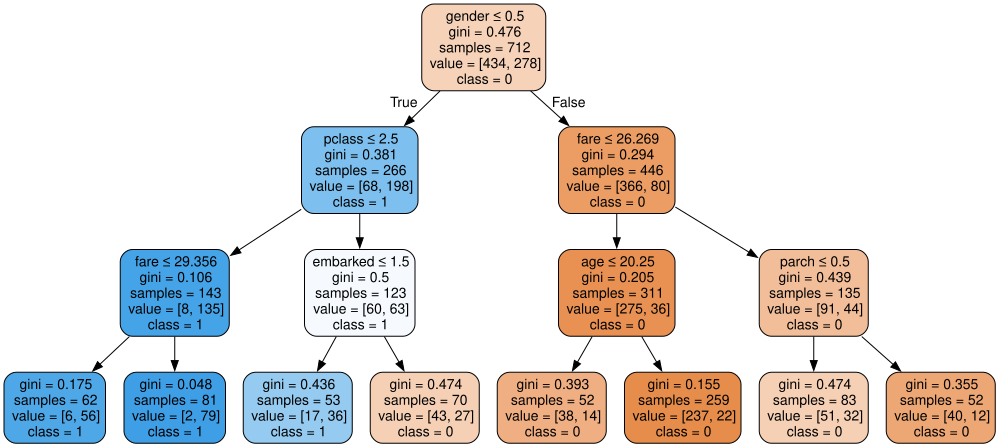

In [2]:
# =============================================================================
# SECTION 1: DATA PREP, EDA & BASELINE DECISION TREE
# Run this cell to get ALL outputs for the Decision Tree section together.
# =============================================================================
# --- 1.1 Import libraries ---
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline
# --- 1.2 Load Titanic dataset ---
titanic = sns.load_dataset('titanic')
sns.get_dataset_names()
titanic.head()
# --- 1.3 Basic EDA ---
titanic.shape
titanic.info()
titanic.head()
titanic.isna().sum()
# --- 1.4 Drop unused columns ---
titanic.drop(columns=['who', 'adult_male', 'embark_town', 'alone',
                      'alive', 'class', 'deck'], inplace=True)
titanic.head()
titanic.isna().sum()
titanic.info()
# --- 1.5 Inspect missing embarked values ---
titanic[titanic['embarked'].isna()]
titanic['embarked'].mode()
# --- 1.6 Missing value treatment ---
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic.iloc[[61, 829], :]
age_missing = titanic[titanic['age'].isna()]
age_missing.sample(10)
age_missing.shape
titanic['age'].median()
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic.info()
titanic.iloc[[667, 368], :]
titanic.info()
# --- 1.7 Rename columns ---
titanic = titanic.rename(columns={"sex": "gender", "SibSp": "siblings", "Parch": "parents_child"})
titanic.head()
titanic.info()
# --- 1.8 Dummy coding of categorical variables ---
for col in titanic.columns:
    if titanic[col].dtype == "object":
        titanic[col] = pd.Categorical(titanic[col]).codes
titanic.head()
titanic.info()
# --- 1.9 Survival counts ---
titanic.groupby('survived').size()
# --- 1.10 Import sklearn ---
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import tree
# --- 1.11 Create features and label ---
x = titanic.drop(['survived'], axis=1, inplace=False)
y = titanic['survived']
x.shape
print('\n')
y.shape
# --- 1.12 Train/test split ---
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=999)
x_train.shape
y_train.shape
x_test.shape
y_test.shape
x_train
y_train
# --- 1.13 Survival rate in train vs test ---
np.round(y_train.sum() / y_train.count() * 100, 2)
print('\n')
np.round(y_test.sum() / y_test.count() * 100, 2)
# --- 1.14 Create Decision Tree model ---
mytree = tree.DecisionTreeClassifier(
    criterion='gini', max_depth=3, min_samples_leaf=50, min_samples_split=75
)
mytree
# --- 1.15 Fit model ---
mytree.fit(x_train, y_train)
# --- 1.16 Predict ---
predicted = mytree.predict(x_test)
predicted
mytree.predict_proba(x_test)
# --- 1.17 Evaluate model performance ---
print(metrics.classification_report(y_test, predicted))
mytree
# --- 1.18 Confusion matrix and accuracy ---
df_confusion = metrics.confusion_matrix(y_test, predicted)
df_confusion
metrics.accuracy_score(y_test, predicted)
sns.heatmap(df_confusion, cmap='Blues',
            xticklabels=['Prediction No', 'Prediction Yes'],
            yticklabels=['Actual No', 'Actual Yes'],
            annot=True, fmt='d')
plt.show()
# --- 1.19 Feature importance and tree visualization ---
x.columns
mytree.feature_importances_
y
import graphviz
dot_data = tree.export_graphviz(
    mytree, out_file=None, feature_names=x.columns,
    class_names=['0', '1'], filled=True, rounded=True, special_characters=True
)
graph = graphviz.Source(dot_data)
graph

In [3]:
# =============================================================================
# SECTION 2: CROSS-VALIDATION DEMO
# Requires Section 1 to be run first (mytree, x_train, y_train).
# =============================================================================
from sklearn.model_selection import cross_val_score
# --- 2.1 Default scoring (accuracy) ---
scores_acc = cross_val_score(mytree, x_train, y_train, cv=5)
scores_acc
# --- 2.2 Recall scoring ---
scores = cross_val_score(mytree, x_train, y_train, cv=5, scoring='recall')
scores

array([0.76223776, 0.7972028 , 0.77464789, 0.83098592, 0.77464789])

array([0.44642857, 0.5       , 0.53571429, 0.63636364, 0.70909091])

In [4]:
# =============================================================================
# SECTION 3: HYPERPARAMETER OPTIMIZATION (GridSearchCV — Decision Tree)
# Requires Section 1 to be run first.
# =============================================================================
from sklearn.model_selection import GridSearchCV
# --- 3.1 Reset tree for tuning ---
mytree = tree.DecisionTreeClassifier(random_state=99, class_weight='balanced')
mytree
# --- 3.2 Define hyperparameter search space ---
my_max_depth = [2, 3, 4, 5, 10]
my_criterion = ['gini', 'entropy']
my_min_samples_leaf = [2, 5, 10, 15, 20, 25]
my_min_samples_split = [2, 5, 10, 15, 50, 100]
len(my_max_depth) * len(my_criterion) * len(my_min_samples_leaf) * len(my_min_samples_split)
# --- 3.3 Build GridSearchCV ---
grid = GridSearchCV(
    estimator=mytree, cv=5, scoring='recall',
    param_grid=dict(
        max_depth=my_max_depth, criterion=my_criterion,
        min_samples_leaf=my_min_samples_leaf,
        min_samples_split=my_min_samples_split
    )
)
grid
# --- 3.4 Fit on training data ---
grid.fit(x_train, y_train)
grid
# --- 3.5 Best model results ---
grid.best_params_
grid.best_estimator_.feature_importances_
print()
x.columns
grid.predict(x_test)
np.round(grid.best_score_, 2) * 100
results = pd.DataFrame(grid.cv_results_)
results.to_csv("results.csv")
# --- 3.6 Evaluate tuned model on test set ---
predicted = grid.predict(x_test)
print(metrics.classification_report(y_test, predicted))


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",99
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

360

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=99)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

...

array([0.17766848, 0.64657247, 0.08641906, 0.        , 0.        ,
       0.06719105, 0.02214894])

Index(['pclass', 'gender', 'age', 'sibsp', 'parch', 'fare', 'embarked'], dtype='object')

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0])

np.float64(81.0)

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       115
           1       0.74      0.61      0.67        64

    accuracy                           0.78       179
   macro avg       0.77      0.74      0.75       179
weighted avg       0.78      0.78      0.78       179



In [5]:
predicted_prob = grid.predict_proba(x_test)
predicted_prob_df = pd.DataFrame(predicted_prob)
predicted_classes_df = pd.DataFrame(predicted)
y_actual_df = pd.DataFrame(y_test.values)
predicted_df = pd.concat([predicted_prob_df, predicted_classes_df, y_actual_df], axis=1)
predicted_df.columns = ['Prob_0', 'Prob_1', 'Predicted_Class', 'Actual_Class']
predicted_prob
predicted_prob[0, 1]
predicted_df.sample(20)

array([[0.74243323, 0.25756677],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.4082232 , 0.5917768 ],
       [0.74243323, 0.25756677],
       [0.31391147, 0.68608853],
       [0.74243323, 0.25756677],
       [0.45582562, 0.54417438],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.        , 1.        ],
       [0.88857796, 0.11142204],
       [0.71187405, 0.28812595],
       [0.        , 1.        ],
       [0.30722004, 0.69277996],
       [0.15470228, 0.84529772],
       [0.71187405, 0.28812595],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.56161616, 0.43838384],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.45582562, 0.54417438],
       [0.88857796, 0.11142204],
       [0.71927555, 0.28072445],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.

np.float64(0.25756676557863495)

,Prob_0,Prob_1,Predicted_Class,Actual_Class
96,0.852180,0.147820,0,0
89,0.711874,0.288126,0,0
141,0.711874,0.288126,0,0
175,0.888578,0.111422,0,0
112,0.888578,0.111422,0,0
20,0.888578,0.111422,0,0
164,0.888578,0.111422,0,0
124,0.711874,0.288126,0,0
146,0.455826,0.544174,1,0
17,0.711874,0.288126,0,0


In [13]:
# =============================================================================
# SECTION 5: THRESHOLD OPTIMIZATION
# Requires Section 3 to be run first (grid).
# =============================================================================
predicted_prob = grid.predict_proba(x_test)
predicted_prob
# --- 5.1 Threshold = 0.25 ---
new_y_test = predicted_prob[:, 1] >= 0.25
new_y_test
print(metrics.classification_report(y_test, new_y_test))
# --- 5.2 Threshold = 0.9 ---
new_y_test = predicted_prob[:, 1] >= 0.9
new_y_test
print(metrics.classification_report(y_test, new_y_test))

array([[0.74243323, 0.25756677],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.4082232 , 0.5917768 ],
       [0.74243323, 0.25756677],
       [0.31391147, 0.68608853],
       [0.74243323, 0.25756677],
       [0.45582562, 0.54417438],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.        , 1.        ],
       [0.88857796, 0.11142204],
       [0.71187405, 0.28812595],
       [0.        , 1.        ],
       [0.30722004, 0.69277996],
       [0.15470228, 0.84529772],
       [0.71187405, 0.28812595],
       [0.85217984, 0.14782016],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.56161616, 0.43838384],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.45582562, 0.54417438],
       [0.88857796, 0.11142204],
       [0.71927555, 0.28072445],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.88857796, 0.11142204],
       [0.

array([ True, False, False, False,  True,  True,  True,  True,  True,
       False, False,  True, False,  True,  True,  True,  True,  True,
       False, False, False,  True, False, False,  True, False,  True,
       False, False, False, False, False,  True,  True, False, False,
        True, False, False, False, False,  True, False,  True,  True,
       False,  True, False, False, False,  True,  True, False,  True,
        True,  True, False, False, False,  True, False, False, False,
       False, False, False, False,  True,  True, False, False, False,
        True,  True, False,  True,  True,  True, False,  True,  True,
       False, False,  True,  True,  True, False, False,  True,  True,
       False,  True, False, False,  True,  True, False, False, False,
        True,  True, False,  True, False,  True,  True,  True, False,
        True, False,  True, False, False,  True, False,  True, False,
        True, False,  True,  True,  True,  True, False,  True,  True,
       False,  True,

              precision    recall  f1-score   support

           0       0.85      0.66      0.75       115
           1       0.57      0.80      0.66        64

    accuracy                           0.71       179
   macro avg       0.71      0.73      0.70       179
weighted avg       0.75      0.71      0.72       179



array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
        True, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False,  True, False, False,
        True, False,  True, False, False,  True, False, False, False,
        True, False,  True, False,  True, False, False, False, False,
       False,  True,

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       115
           1       1.00      0.38      0.55        64

    accuracy                           0.78       179
   macro avg       0.87      0.69      0.70       179
weighted avg       0.83      0.78      0.74       179

